In [1]:
from astropy.io import fits
from astropy import units, constants
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner
from voigt_fit_lib import *
import os
import pickle

Load in the files

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/'

First, the FUV files

In [3]:
spec_fits_fuv = fits.open(rootdir + 'FUV/PG1522+101_FUV_wavecal_new.fits')
lsf_fits_fuv = fits.open(rootdir + 'FUV/PG1522_COS_FUV_wavcal2022_lsf_ZQ.fits')

Then, the NUV files

In [4]:
spec_fits_nuv = fits.open(rootdir + 'G185M/PG1522+101_NUV_wavecal_new.fits')
lsf_fits_nuv = fits.open(rootdir + 'G185M/PG1522_COS_NUV_wavcal2022_lsf.fits')

Then, the STIS files

In [5]:
spec_fits_stis = fits.open(rootdir + 'STIS/PG1522+101_E230M_new.fits')
lsf_fits_stis = fits.open(rootdir + 'STIS/PG1522_STIS_NUV_wavcal2022_lsf.fits')

Then, the HIRES files

In [6]:
spec_fits_hires = fits.open(rootdir + 'HIRES/PG1522+101_HIRES.fits')
lsf_fits_hires = fits.open(rootdir + 'HIRES/PG1522_HIRES_wavcal2023_lsf.fits')

Compile a list of the spectra, continuum nodes, and IDs for all detectors

In [7]:
spec_fits_list = [spec_fits_fuv, spec_fits_nuv, spec_fits_stis, spec_fits_hires]
lsf_fits_list = [lsf_fits_fuv, lsf_fits_nuv, lsf_fits_stis, lsf_fits_hires]

Systemic redshift

In [8]:
z_sys = 1.25937372 #1.2594

In [9]:
#np.round(1.2594 - ((1+1.2594)*3.49/3e+5), 8)

# CIV

## CIV 1548

In [10]:
civ_1548_hires = ion_transition('CIV', 1548, 'C', z_sys, 'HIRES')

In [11]:
civ_1548_hires.grab_ion_transition_info()

In [12]:
civ_1548_hires.grab_ion_transition_spec(spec_fits_list)

In [13]:
civ_1548_hires.cont_norm_flux(v_abs_range=[-50,50], degree=1)

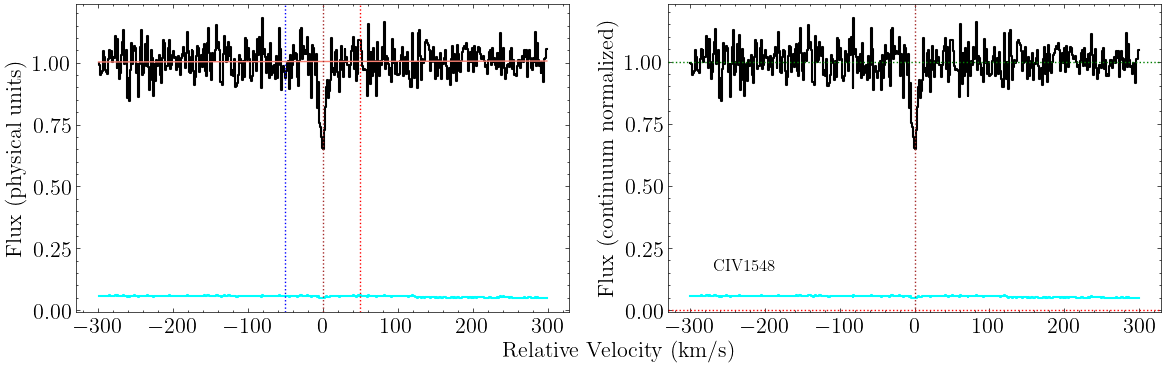

In [14]:
fig, ax = civ_1548_hires.plot_ion_transition_spec_cont()

In [15]:
#civ_1548_nuv.get_EW_total(-50,50)

In [16]:
civ_1548_hires.grab_ion_transition_lsf(lsf_fits_list)

In [17]:
civ_1548_hires.init_ion_transition(init_values = np.array([[13.0, 10, 0]]), 
                             lsf_convolve = True)

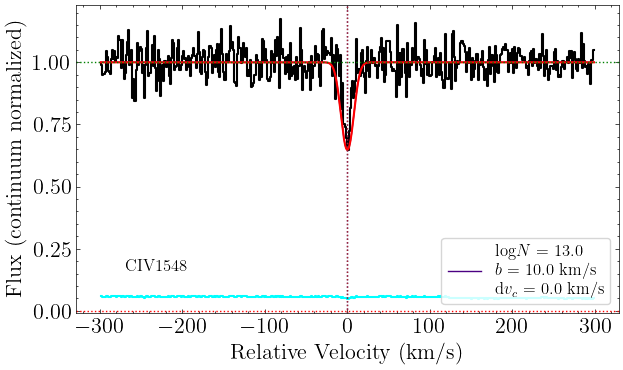

In [18]:
fig, ax = civ_1548_hires.plot_ion_transition_init_fit()

In [19]:
civ_1548_hires.fit_ion_transition()

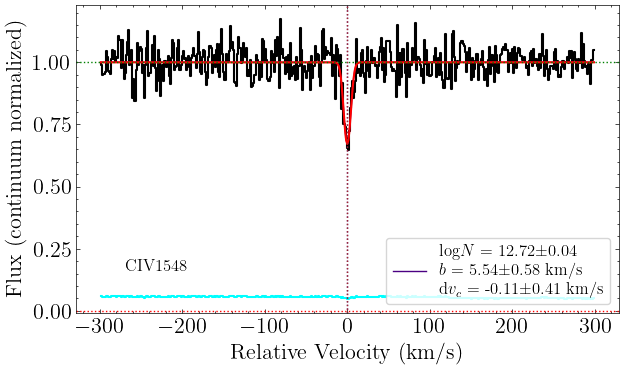

In [20]:
fig, ax = civ_1548_hires.plot_ion_transition_best_fit()

## CIV 1550

In [21]:
civ_1550_hires = ion_transition('CIV', 1550, 'C', z_sys, 'HIRES')

In [22]:
civ_1550_hires.grab_ion_transition_info()

In [23]:
civ_1550_hires.grab_ion_transition_spec(spec_fits_list)

In [24]:
civ_1550_hires.cont_norm_flux(v_abs_range=[-50,50], degree=1)

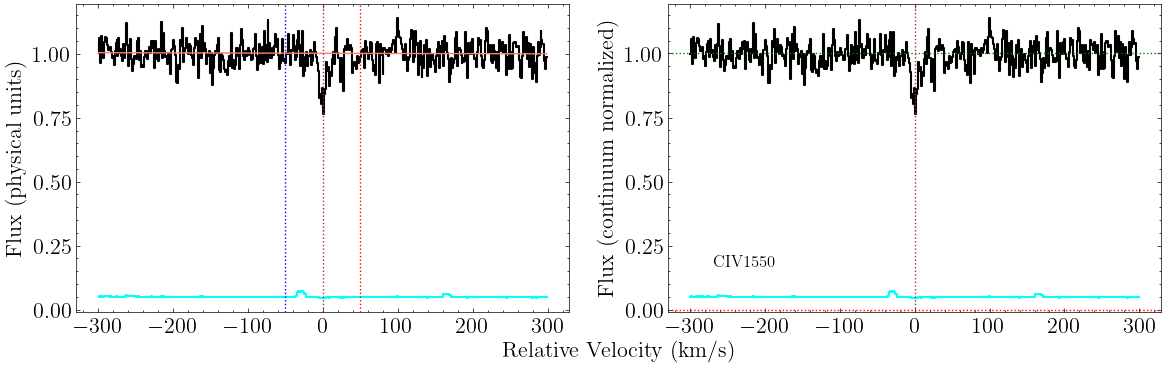

In [25]:
fig, ax = civ_1550_hires.plot_ion_transition_spec_cont()

In [26]:
#civ_1548_nuv.get_EW_total(-50,50)

In [27]:
civ_1550_hires.grab_ion_transition_lsf(lsf_fits_list)

In [28]:
civ_1550_hires.init_ion_transition(init_values = np.array([[13.0, 5, 0]]), 
                             lsf_convolve = True)

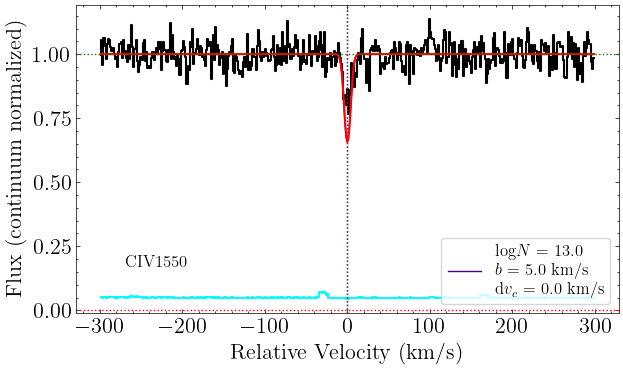

In [29]:
fig, ax = civ_1550_hires.plot_ion_transition_init_fit()

In [30]:
civ_1550_hires.fit_ion_transition()

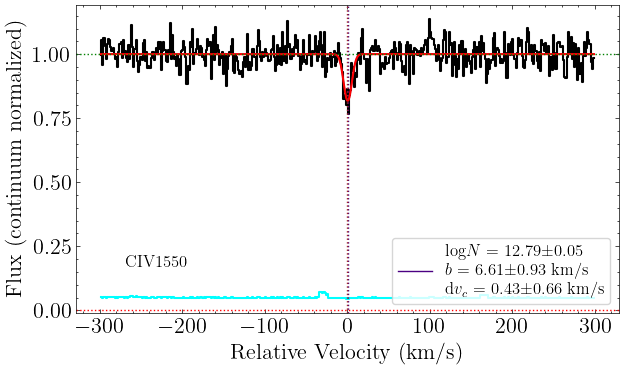

In [31]:
fig, ax = civ_1550_hires.plot_ion_transition_best_fit()

## CIV ion

In [32]:
civ = ion(z_sys, 'CIV', [civ_1548_hires, civ_1550_hires])

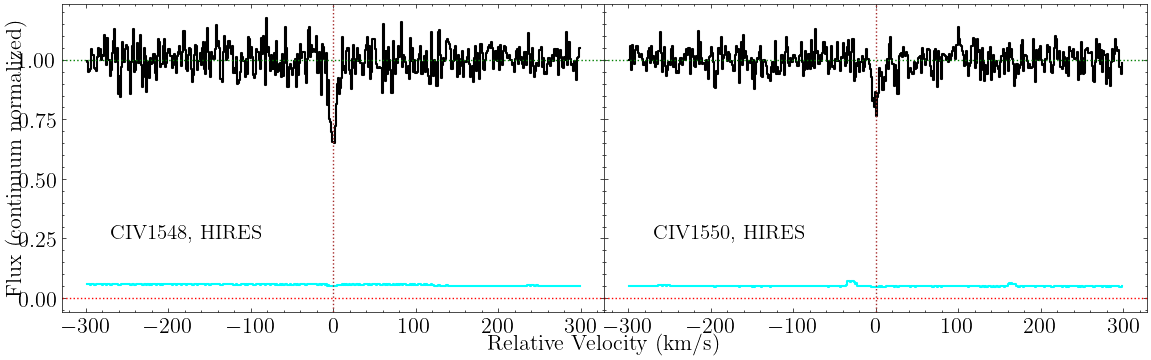

In [33]:
fig, axes = civ.plot_ion()

In [34]:
civ.init_ion([[[12.85, 5, 0]],
              [[12.85, 5, 0]]])

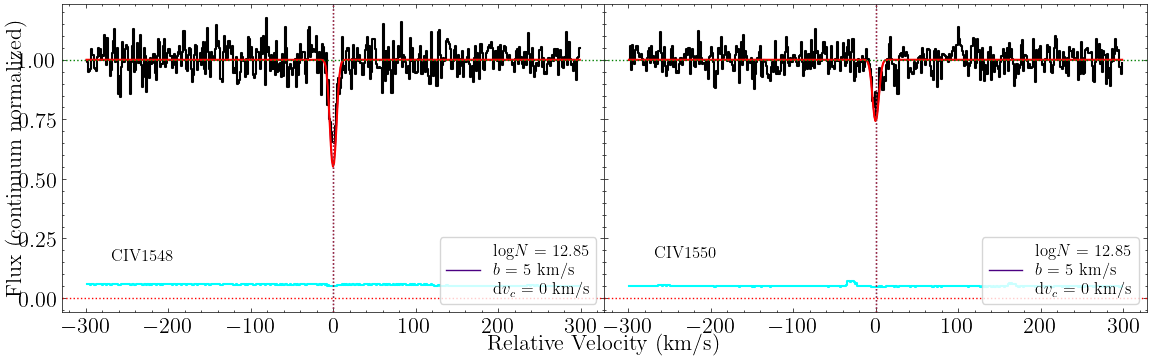

In [35]:
fig, axes = civ.plot_ion_init_fit()

In [36]:
civ.fit_ion(tie_params_list = [['it1c1_logN', 'it2c1_logN'],
                               ['it1c1_b', 'it2c1_b'],
                               ['it1c1_dv_c', 'it2c1_dv_c'],
                              ])

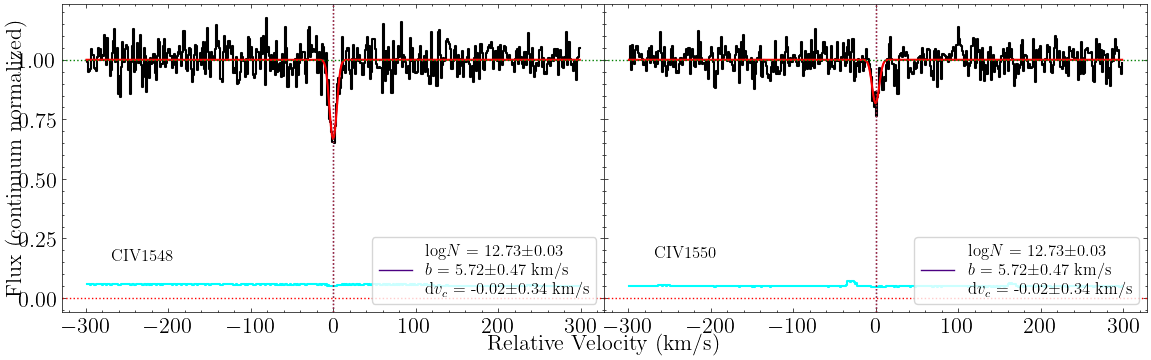

In [37]:
fig, axes = civ.plot_ion_best_fit()

In [38]:
#civ.fit_ion_emcee(loaddir=rootdir, scale_covar=1e-7, n_walkers=100, n_steps=2500)
civ.fit_ion_emcee(load=True, loaddir=rootdir)

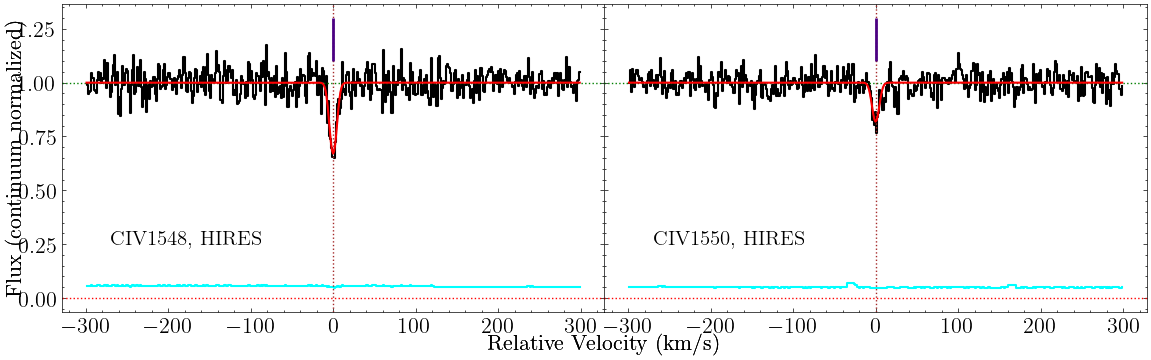

In [39]:
fig, axes = civ.plot_samples()

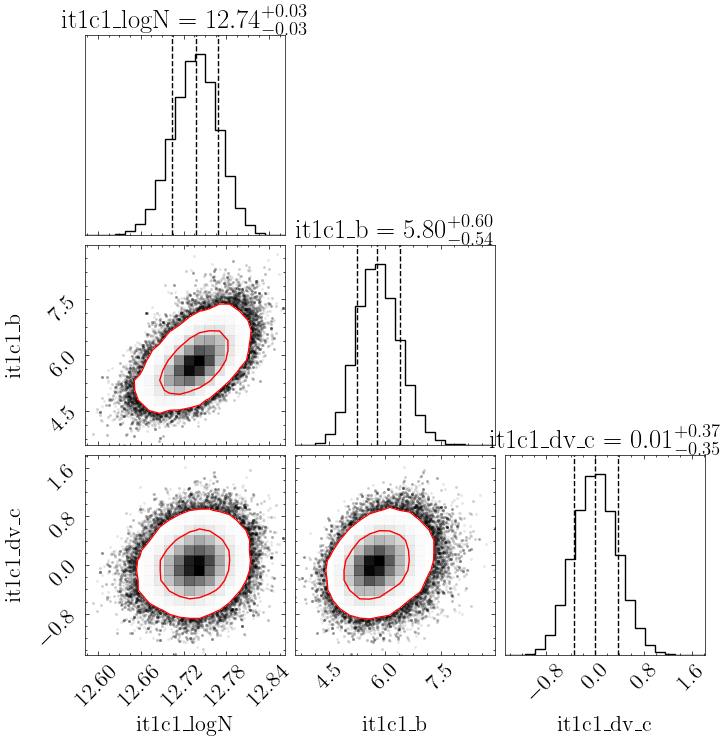

In [40]:
civ.plot_corner()

# CIII

## CIII 977

In [85]:
ciii_977_stis = ion_transition('CIII', 977, 'C', z_sys, 'STIS')

In [86]:
ciii_977_stis.grab_ion_transition_info()

In [92]:
ciii_977_stis.grab_ion_transition_spec(spec_fits_list, masks=[[-60,-20],[40,140]])

In [93]:
ciii_977_stis.cont_norm_flux(v_abs_range=[-100,100], degree=1)

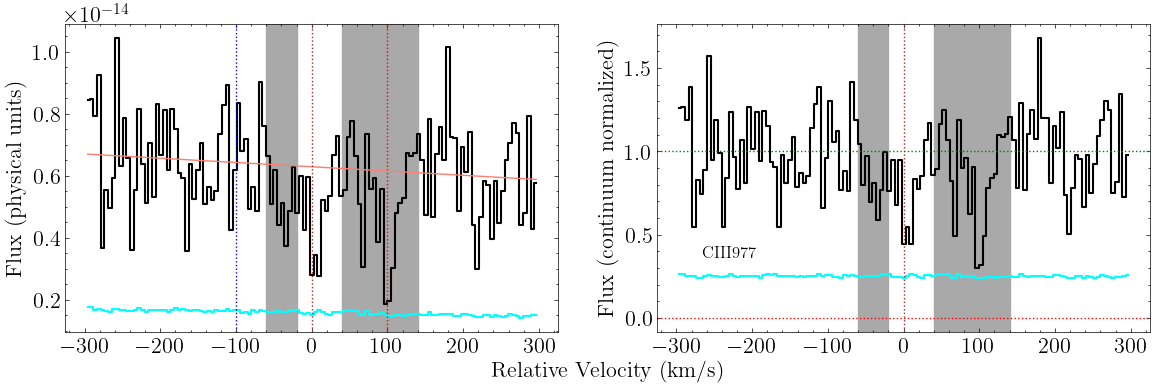

In [94]:
fig, ax = ciii_977_stis.plot_ion_transition_spec_cont()

In [95]:
ciii_977_stis.grab_ion_transition_lsf(lsf_fits_list)

In [96]:
ciii_977_stis.init_ion_transition(init_values = np.array([[13.0, 5, 0]]), 
                             lsf_convolve = True)

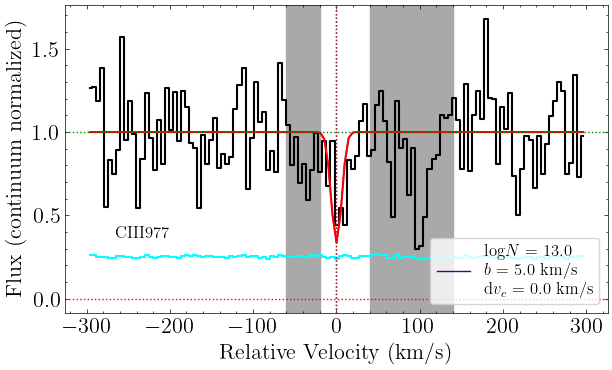

In [97]:
fig, ax = ciii_977_stis.plot_ion_transition_init_fit()

In [98]:
ciii_977_stis.fit_ion_transition()

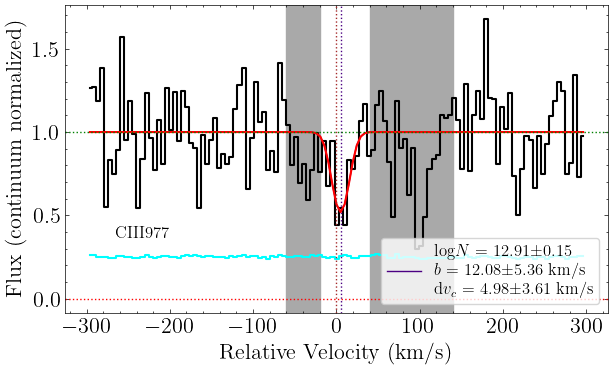

In [99]:
fig, ax = ciii_977_stis.plot_ion_transition_best_fit()

## CIII ion

In [100]:
ciii = ion(z_sys, 'CIII', [ciii_977_stis])

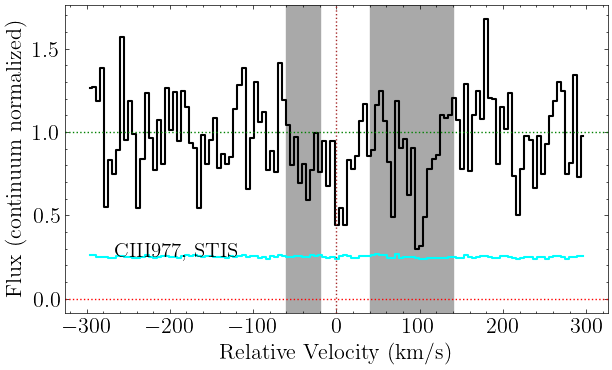

In [101]:
fig, axes = ciii.plot_ion()

In [114]:
ciii.init_ion([[[12.85, 6, 5]]])

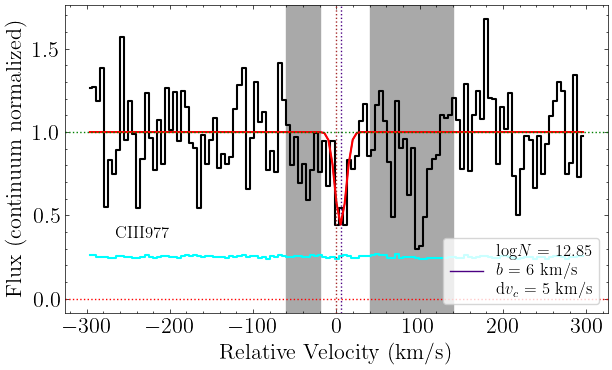

In [115]:
fig, axes = ciii.plot_ion_init_fit()

In [131]:
ciii.fit_ion(fix_params_list=['it1c1_dv_c', 'it1c1_b'],
            upper_bounds_dict = {'it1c1_logN':14.3})

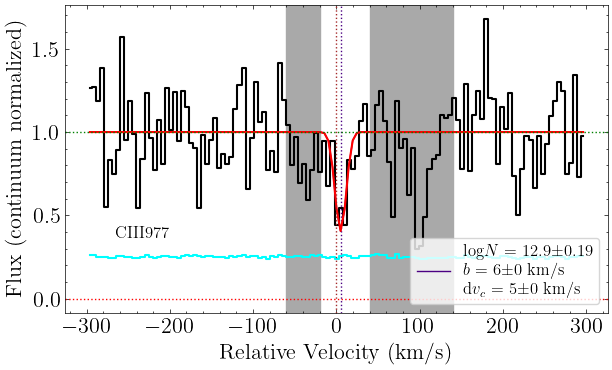

In [132]:
fig, axes = ciii.plot_ion_best_fit()

In [137]:
#ciii.fit_ion_emcee(loaddir=rootdir, scale_covar=1e-7, n_walkers=100, n_steps=2500)
ciii.fit_ion_emcee(load=True, loaddir=rootdir)

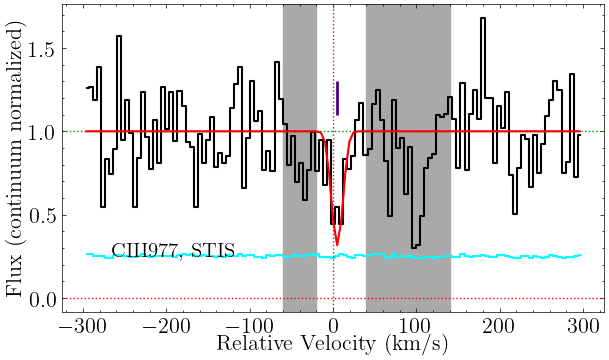

In [138]:
fig, axes = ciii.plot_samples()

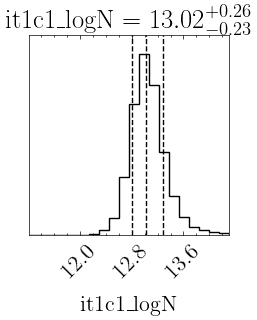

In [139]:
ciii.plot_corner()

# OIII

## OIII 702

In [70]:
oiii_702_fuv = ion_transition('OIII', 702, 'O', z_sys, 'FUV')

In [71]:
oiii_702_fuv.grab_ion_transition_info()

In [81]:
oiii_702_fuv.grab_ion_transition_spec(spec_fits_list, masks=[[-280,-140],[40,160]])

In [82]:
oiii_702_fuv.cont_norm_flux(v_abs_range=[-50,65], degree=1)

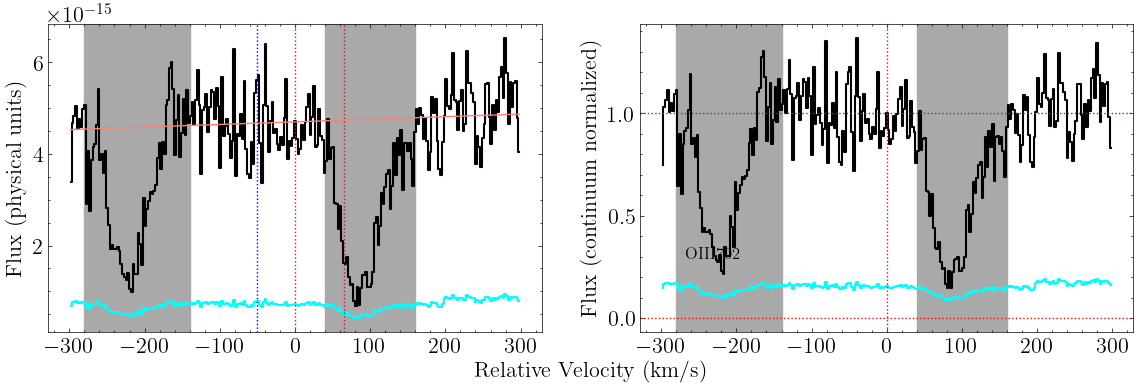

In [83]:
fig, ax = oiii_702_fuv.plot_ion_transition_spec_cont()

# OIV

## OIV 554

In [122]:
oiv_554_fuv = ion_transition('OIV', 554, 'O', z_sys, 'FUV')

In [123]:
oiv_554_fuv.grab_ion_transition_info()

In [158]:
oiv_554_fuv.grab_ion_transition_spec(spec_fits_list, masks=[[-300,-60],[20,100],[140,300]])

In [161]:
oiv_554_fuv.cont_norm_flux(v_abs_range=[-30,20], degree=1)

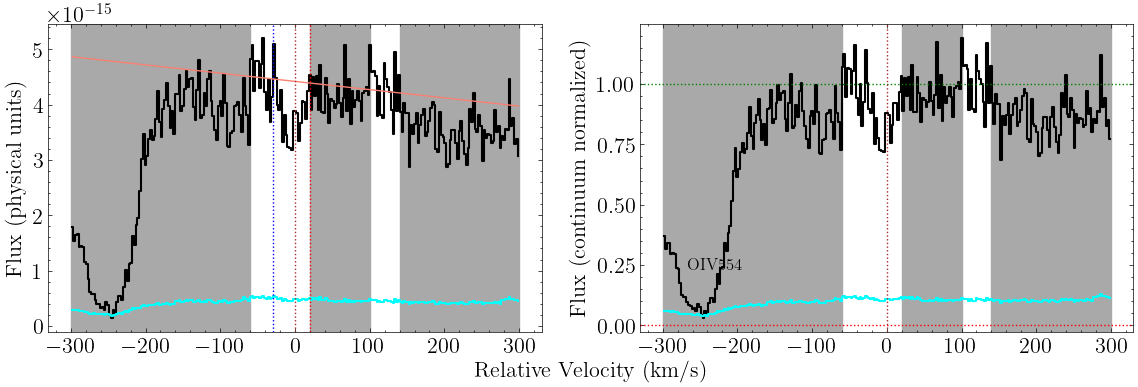

In [162]:
fig, ax = oiv_554_fuv.plot_ion_transition_spec_cont()

In [163]:
#civ_1548_nuv.get_EW_total(-50,50)

In [164]:
oiv_554_fuv.grab_ion_transition_lsf(lsf_fits_list)

In [175]:
oiv_554_fuv.init_ion_transition(init_values = np.array([[13.6, 5, 0]]), 
                             lsf_convolve = True)

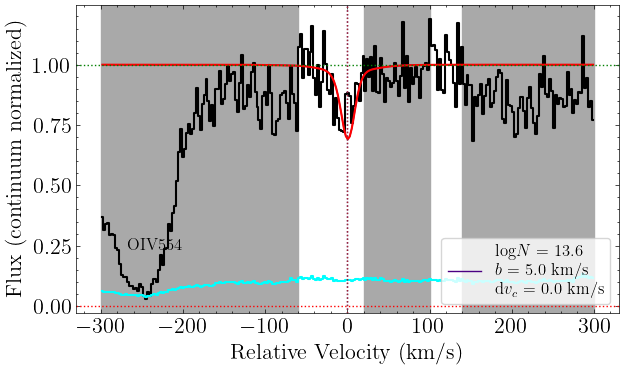

In [176]:
fig, ax = oiv_554_fuv.plot_ion_transition_init_fit()

In [177]:
oiv_554_fuv.fit_ion_transition()

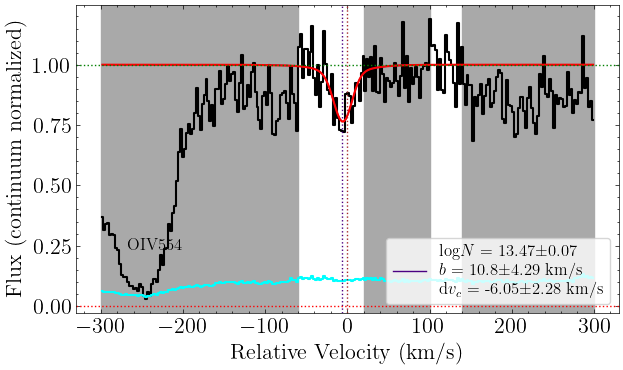

In [178]:
fig, ax = oiv_554_fuv.plot_ion_transition_best_fit()

## OIV 787

In [140]:
oiv_787_fuv = ion_transition('OIV', 787, 'O', z_sys, 'FUV')

In [141]:
oiv_787_fuv.grab_ion_transition_info()

In [155]:
oiv_787_fuv.grab_ion_transition_spec(spec_fits_list, masks=[[-300,-260],[180,300]])

In [156]:
oiv_787_fuv.cont_norm_flux(v_abs_range=[0,150], degree=1)

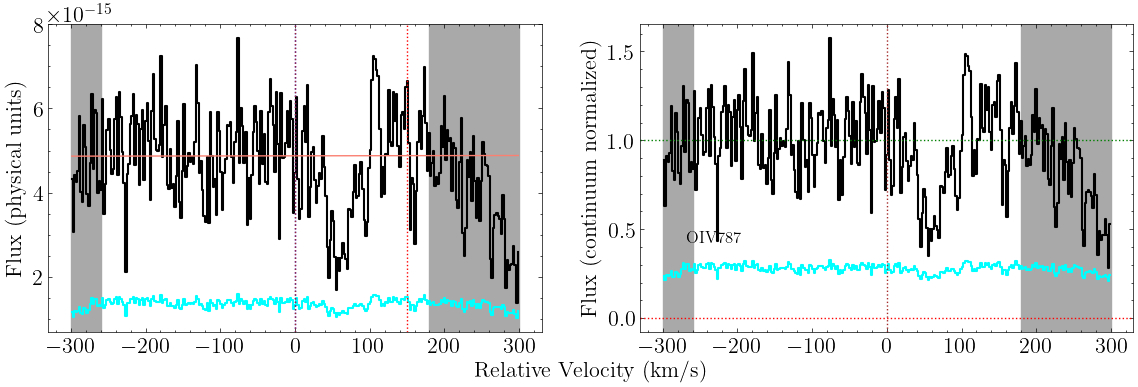

In [157]:
fig, ax = oiv_787_fuv.plot_ion_transition_spec_cont()

In [158]:
oiv_787_fuv.grab_ion_transition_lsf(lsf_fits_list)

In [167]:
oiv_787_fuv.init_ion_transition(init_values = np.array([[13.4, 10, -6]]), 
                             lsf_convolve = True)

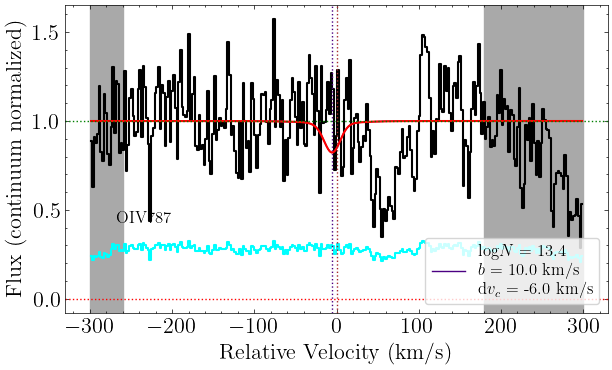

In [168]:
fig, ax = oiv_787_fuv.plot_ion_transition_init_fit()

In [199]:
oiv_787_fuv.fit_ion_transition()

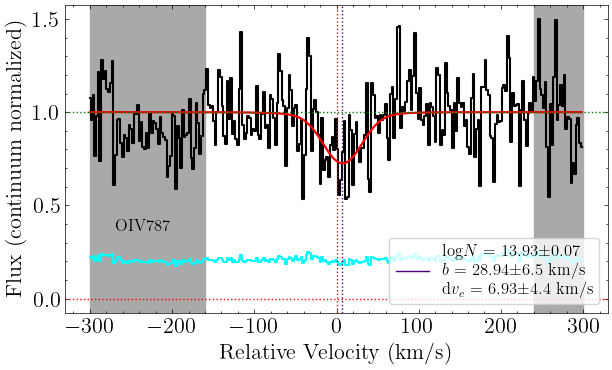

In [200]:
fig, ax = oiv_787_fuv.plot_ion_transition_best_fit()

# HI

## HI 1215

In [41]:
hi_1215_stis = ion_transition('HI', 1215, 'H', z_sys, 'STIS')

In [42]:
hi_1215_stis.grab_ion_transition_info()

In [43]:
hi_1215_stis.grab_ion_transition_spec(spec_fits_list)

In [44]:
hi_1215_stis.cont_norm_flux(v_abs_range=[-270,60], degree=1)

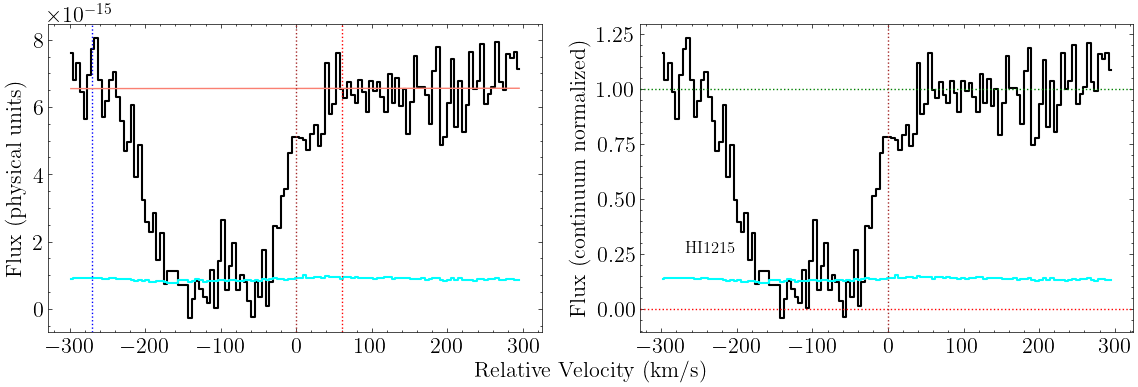

In [45]:
fig, ax = hi_1215_stis.plot_ion_transition_spec_cont()

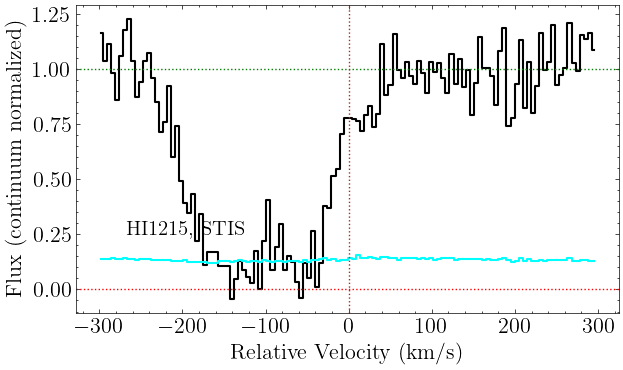

In [46]:
fig, ax = hi_1215_stis.plot_ion_transition_spec()

In [47]:
hi_1215_stis.grab_ion_transition_lsf(lsf_fits_list)

In [48]:
hi_1215_stis.init_ion_transition(init_values = np.array([[13.0, 10, -3.5],
                                                         [15.0, 20,-80], 
                                                         [15.0, 20, -100]]), 
                             lsf_convolve = True)

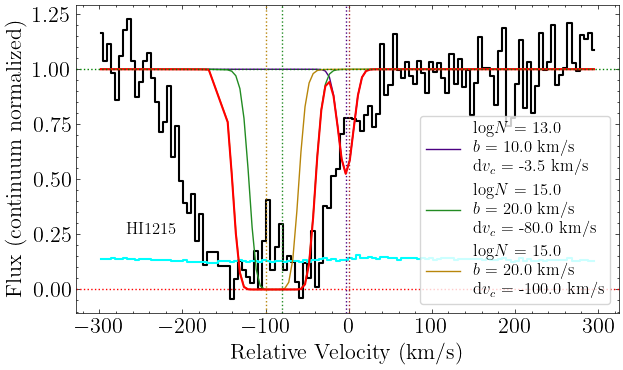

In [49]:
fig, ax = hi_1215_stis.plot_ion_transition_init_fit()

In [50]:
hi_1215_stis.fit_ion_transition(fix_params_list = ['it1c1_dv_c'])

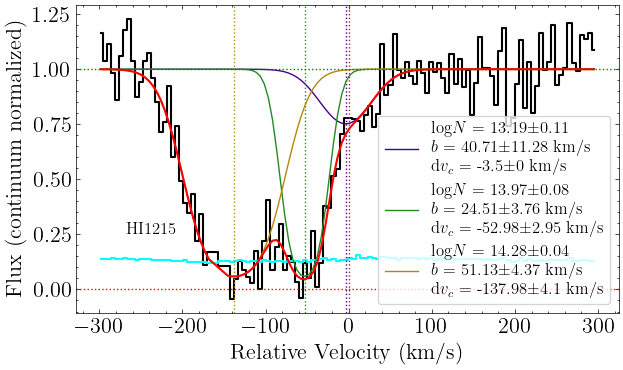

In [51]:
fig, ax = hi_1215_stis.plot_ion_transition_best_fit()

## HI 972

In [52]:
hi_972_nuv = ion_transition('HI', 972, 'H', z_sys, 'STIS')

In [53]:
hi_972_nuv.grab_ion_transition_info()

In [54]:
hi_972_nuv.grab_ion_transition_spec(spec_fits_list)

In [55]:
hi_972_nuv.cont_norm_flux(v_abs_range=[-250,250], degree=1)

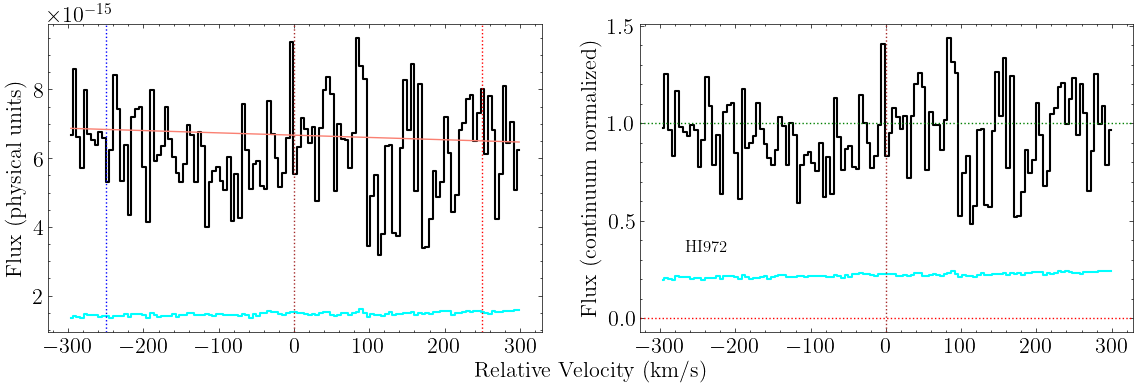

In [56]:
fig, axes = hi_972_nuv.plot_ion_transition_spec_cont()

In [57]:
hi_972_nuv.grab_ion_transition_lsf(lsf_fits_list)

In [58]:
hi_972_nuv.init_ion_transition(init_values = np.array([[13.1, 37, -3.5],
                                                         [14.0, 24, -56], 
                                                         [14.3, 51, -140]]), 
                             lsf_convolve = True)

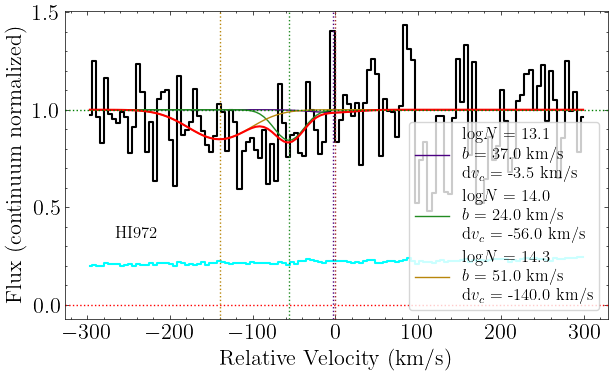

In [59]:
fig, ax = hi_972_nuv.plot_ion_transition_init_fit()

## HI 1025

In [96]:
hi_1025_stis = ion_transition('HI', 1025, 'H', z_sys, 'STIS')

In [97]:
hi_1025_stis.grab_ion_transition_info()

In [98]:
hi_1025_stis.grab_ion_transition_spec(spec_fits_list)

In [99]:
hi_1025_stis.cont_norm_flux(v_abs_range=[-250,50], degree=1)

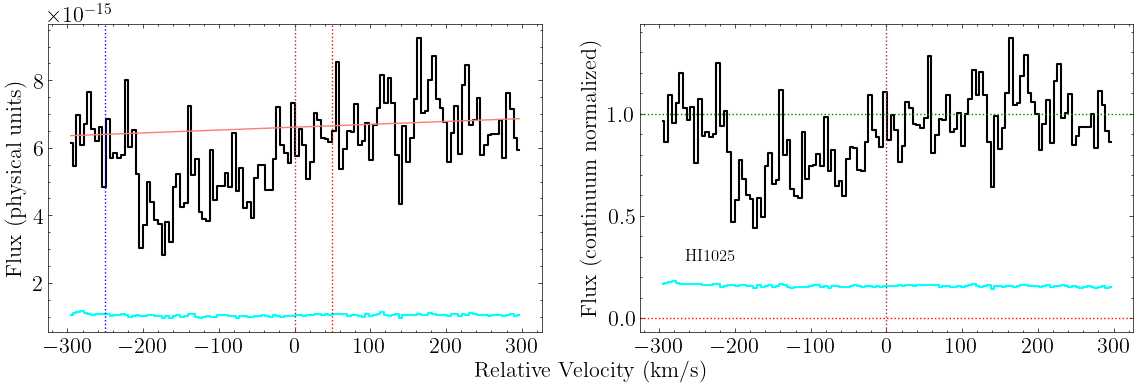

In [100]:
fig, axes = hi_1025_stis.plot_ion_transition_spec_cont()

In [101]:
hi_1025_stis.grab_ion_transition_lsf(lsf_fits_list)

In [102]:
hi_1025_stis.init_ion_transition(init_values = np.array([[13.1, 37, -3.5],
                                                         [14.0, 24, -56], 
                                                         [14.3, 51, -140]]), 
                             lsf_convolve = True)

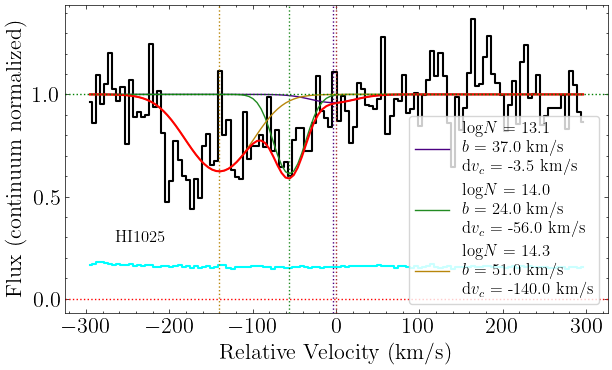

In [103]:
fig, ax = hi_1025_stis.plot_ion_transition_init_fit()